In [138]:
import os
from os import listdir

from os.path import isfile, join, dirname, basename
import pandas as pd

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

In [140]:
import matplotlib.gridspec as gridspec

In [141]:
%run analysis_utils.py

In [142]:
def process_and_sort(df):
    model_means = df.groupby('experiment')['mean'].mean().reset_index(name='mean_overall')
    # model_means = df.groupby('experiment')['mean'].median().reset_index(name='mean_overall')

    model_groups = df[['experiment', 'group']].drop_duplicates()

    sorted_models = model_means.merge(model_groups, on='experiment')
    sorted_models = sorted_models.sort_values(by=['group', 'mean_overall'], ascending=[True, False])
    sorted_model_order = sorted_models['experiment'].tolist()

    heatmap_df = df.pivot(index='experiment_name', columns='experiment', values='mean')
    heatmap_df = heatmap_df[sorted_model_order]

    return heatmap_df, sorted_models

In [143]:

def plot_composite_by_group_panels(heatmap_df, sorted_models, metric, clf='avg', save_dir='.'):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.gridspec as gridspec
    import numpy as np
    from os.path import join
    from matplotlib.cm import get_cmap
    from matplotlib.colors import Normalize

    sorted_models = sorted_models.round(2)
    heatmap_df = heatmap_df.round(2)

    # Calculate row-wise averages and sort
    row_avg = heatmap_df.mean(axis=1)
    heatmap_df = heatmap_df.loc[row_avg.sort_values(ascending=False).index]

    grouped = sorted_models.groupby('group')
    n_groups = len(grouped)
    palette = sns.color_palette("husl", n_groups)
    color_map = dict(zip(grouped.groups.keys(), palette))

    global_vmin = heatmap_df.min().min()
    global_vmax = heatmap_df.max().max()
    norm = Normalize(vmin=global_vmin, vmax=global_vmax)
    cmap = get_cmap('viridis')

    total_models = sum(len(group_df) for _, group_df in grouped)
    fig = plt.figure(figsize=(max(6, total_models * 0.5 + 1.5), max(6, heatmap_df.shape[0] * 0.6)))

    group_model_counts = [len(group_df) for _, group_df in grouped]

    # gs = gridspec.GridSpec(
    #     3,
    #     n_groups + 2,
    #     width_ratios=group_model_counts + [0.2, 1.0],
    #     height_ratios=[1.2, 6, 0.4],
    #     hspace=0.3,
    #     wspace=0.1
    # )

    gs = gridspec.GridSpec(
        3,
        n_groups + 2,  # +2 for row avg and colorbar
        width_ratios=group_model_counts + [1.0, 0.2],  # row avg, colorbar
        height_ratios=[1.2, 6, 0.4],
        hspace=0.3,
        wspace=0.1
    )
        
    for i, (group_name, group_df) in enumerate(grouped):
        # cbar = (i == n_groups - 1)
        # cbar_ax = fig.add_subplot(gs[1, -2]) if cbar else None

        cbar = (i == n_groups - 1)
        cbar_ax = fig.add_subplot(gs[1, -1]) if cbar else None  # now last column
        
        color = color_map[group_name]
        model_names = group_df['experiment'].tolist()
        model_avg = group_df['mean_overall'].tolist()
        group_heatmap = heatmap_df[model_names]

        # Top bar plot
        ax_top = fig.add_subplot(gs[0, i])
        bars = ax_top.bar(range(len(model_avg)), model_avg, color=color)
        ax_top.set_xticks([])
        ax_top.set_yticks([])
        # ax_top.set_title(f"{group_name}\nAvg {metric}", fontsize=6)
        ax_top.set_ylim(0.7, 1)

        # Remove all spines (bounding boxes)
        for spine in ax_top.spines.values():
            spine.set_visible(False)

        for idx, bar in enumerate(bars):
            height = bar.get_height()
            ax_top.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f"{height:.2f}", ha='center', va='bottom', fontsize=6)

        # Heatmap
        ax_heatmap = fig.add_subplot(gs[1, i])
        sns.heatmap(
            group_heatmap,
            ax=ax_heatmap,
            annot=True,
            fmt=".2f",
            cmap='viridis',
            vmin=global_vmin,
            vmax=global_vmax,
            cbar=cbar,
            cbar_ax=cbar_ax,
            xticklabels=False,
            annot_kws={"size": 6}
        )
        ax_heatmap.set_xticklabels([])
        ax_heatmap.tick_params(axis='x', bottom=False)
        ax_heatmap.set_xlabel(group_name)
        if i != 0:
            ax_heatmap.set_ylabel("")
            ax_heatmap.set_yticks([])
            ax_heatmap.set_yticklabels([])

        xticklabels = model_names
        ax_heatmap.tick_params(axis='x', rotation=90, labelsize=8)
        ax_heatmap.set_ylabel('')

        # Bottom color bar
        ax_bottom = fig.add_subplot(gs[2, i])
        for j in range(len(model_names)):
            ax_bottom.add_patch(plt.Rectangle((j, 0), 1, 1, color=color))
            
        ax_bottom.set_xlim(0, len(model_names))
        ax_bottom.set_ylim(0, 1)
        ax_bottom.axis('off')
        for j, model in enumerate(model_names):
            ax_bottom.text(j + 0.5, -0.2, model, ha='right', va='top', rotation=90, fontsize=10, rotation_mode='anchor')

     # Right-side bar plot: row average
    # ax_right_bar = fig.add_subplot(gs[1, -1])
    # avg_vals = heatmap_df.mean(axis=1)
    # y_positions = np.arange(len(avg_vals))
    
    # Right-side bar plot: row average (now second-to-last column)
    ax_right_bar = fig.add_subplot(gs[1, -2])
    avg_vals = heatmap_df.mean(axis=1)
    y_positions = np.arange(len(avg_vals))
    colors = [cmap(norm(val)) for val in avg_vals]

    ax_right_bar.barh(y_positions, avg_vals.values, color=colors)

    ax_right_bar.invert_yaxis()  # Align with heatmap rows
    ax_right_bar.set_xlim(0.4, 1.0)
    ax_right_bar.set_yticks([])
    ax_right_bar.set_xticks([])
    ax_right_bar.set_xlabel(f"Avg {metric}", fontsize=5)

    for spine in ax_right_bar.spines.values():
        spine.set_visible(False)
        

    # Use heatmap order and colormap for coloring
    colors = [cmap(norm(val)) for val in avg_vals]

    bars = ax_right_bar.barh(y_positions, avg_vals.values, color=colors)
    
    if cbar_ax is not None:
        cbar_ax.tick_params(labelsize=6)  # Control colorbar tick font size here

    # Align and remove ticks
    # ax_right_bar.invert_yaxis()  # Align top-down with heatmap
    # ax_right_bar.set_xlim(0.7, 1.0)
    # ax_right_bar.set_yticks([])
    # ax_right_bar.set_xticks([])
    # ax_right_bar.set_xlabel(f"Avg {metric}", fontsize=8)

    # Remove border/spines
    for spine in ax_right_bar.spines.values():
        spine.set_visible(False)

    # Group legend (optional)
    fig.subplots_adjust(bottom=0.25)
    legend_handles = [plt.Line2D([0], [0], color=c, lw=10) for c in color_map.values()]
    # fig.legend(legend_handles, color_map.keys(), loc='lower center', ncol=n_groups)

    output_path = join(save_dir, f'{metric}_{clf}.png')
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"Grouped panel heatmap saved to {output_path}")
    return fig

In [144]:
metrics= ['AUC', 'F1', 'AUPRC', 'Recall', 'Precision', 'Accuracy']

In [145]:
clfs = ['vote', 'mil', 'avg'] #['avg', 'mil']

In [146]:
test_df = pd.read_csv('results/classification_metrcis.csv')

In [147]:
test_df

,Unnamed: 0,AUC,AUPRC,Accuracy,F1,Precision,Recall,model,exp,strategy,group
0,0,1.000,1.000000,0.666667,0.400000,0.333333,0.50,STATE,T-cell exhaustion,vote,Other
1,1,0.500,0.450000,0.666667,0.400000,0.333333,0.50,STATE,T-cell exhaustion,vote,Other
2,2,0.750,0.750000,0.666667,0.400000,0.333333,0.50,STATE,T-cell exhaustion,vote,Other
3,3,1.000,1.000000,0.666667,0.400000,0.333333,0.50,STATE,T-cell exhaustion,vote,Other
4,4,0.750,0.500000,0.800000,0.444444,0.400000,0.50,STATE,T-cell exhaustion,vote,Other
...,...,...,...,...,...,...,...,...,...,...,...
973,333,0.875,0.833333,0.750000,0.733333,0.833333,0.75,scVI,IO Response,avg,Baseline
974,334,1.000,1.000000,1.000000,1.000000,1.000000,1.00,scVI,IO Response,avg,Baseline
975,335,0.500,0.750000,0.500000,0.500000,0.500000,0.50,scVI,IO Response,avg,Baseline
976,336,0.500,0.750000,0.250000,0.200000,0.166667,0.25,scVI,IO Response,avg,Baseline


In [148]:
'experiment_name', 'experiment', 'group', 'mean'

('experiment_name', 'experiment', 'group', 'mean')

In [149]:
auprc_df = test_df[['AUPRC', 'model', 'exp', 'group','strategy']]

In [150]:
auprc_df = test_df[['AUPRC', 'model', 'exp', 'group','strategy']]
auprc_df_avg = auprc_df[auprc_df['strategy'] == 'avg']
auprc_df_avg
dd = auprc_df_avg.groupby(['exp', 'group', 'model', 'strategy']).mean().reset_index()
dd['mean'] = dd['AUPRC']
dd['experiment_name'] = dd['exp'] 
dd['experiment'] = dd['model']
heatmap_df_grouped, sorted_models = process_and_sort(dd)
heatmap_df_grouped
# heatmap_df_grouped  = heatmap_df_grouped.drop('luad_cancer_stage', axis=0)

experiment,scVI,PCA [100],GF-V2 [cancer],GF-V1,STATE,scFoundation,SCimiarity,CellPLM,scGPT [cancer],scGPT
experiment_name,,,,,,,,,,
ER+ vs TNBC,0.983333,0.802222,0.966667,0.784444,0.966667,1.000000,0.940000,0.923333,0.950000,0.728889
IO Response,0.866667,0.550000,0.866667,0.916667,0.916667,0.833333,0.950000,0.900000,0.916667,0.816667
MMRd vs MMRp,0.860495,0.732118,0.817455,0.879485,NaN,0.823999,NaN,0.850786,0.674884,0.670916
T-cell exhaustion,0.806667,0.526667,0.665000,0.640000,0.756667,0.800000,0.823333,0.663333,0.873333,0.633333
Treatment Naive vs Anti PD1,0.815859,0.954728,0.944212,0.817944,0.974683,1.000000,0.901190,0.792862,0.846237,0.744311
Treatment Naive vs Neoadjuvant Chemo,0.543571,0.528571,0.866667,0.683333,0.690000,0.806667,0.551905,0.403333,0.635238,0.645238
Treatment Naive vs TKI treated,1.000000,0.625000,1.000000,1.000000,1.000000,0.875000,1.000000,1.000000,1.000000,NaN


/tmp/ipykernel_113843/3215541062.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to ./plots/AUPRC_avg.png


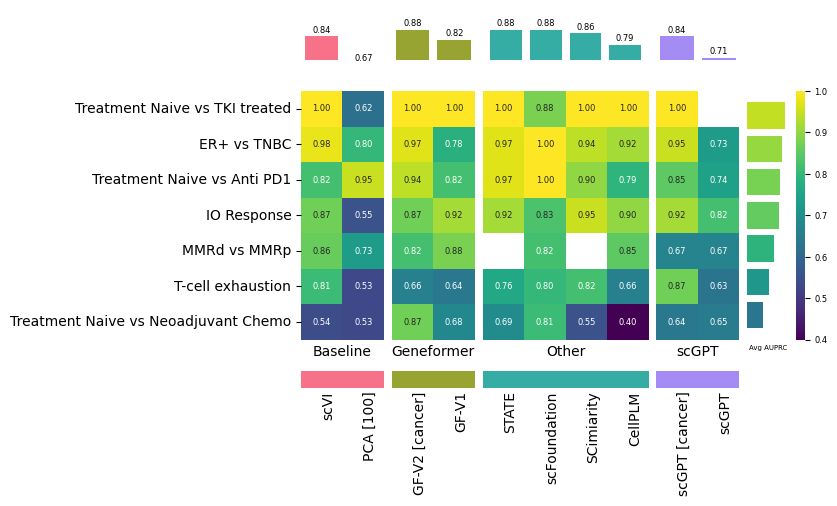

In [151]:
m = 'AUPRC'
clf = 'avg'
plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='./plots')

In [152]:
auprc_df = test_df[['AUPRC', 'model', 'exp', 'group','strategy']]
auprc_df_avg = auprc_df[auprc_df['strategy'] == 'MIL']
auprc_df_avg
dd = auprc_df_avg.groupby(['exp', 'group', 'model', 'strategy']).mean().reset_index()
dd['mean'] = dd['AUPRC']
dd['experiment_name'] = dd['exp'] 
dd['experiment'] = dd['model']
heatmap_df_grouped, sorted_models = process_and_sort(dd)
heatmap_df_grouped
# heatmap_df_grouped  = heatmap_df_grouped.drop('luad_cancer_stage', axis=0)

experiment,scVI,PCA [100],GF-V2 [cancer],GF-V1,STATE,scFoundation,SCimiarity,CellPLM,scGPT,scGPT [cancer]
experiment_name,,,,,,,,,,
ER+ vs TNBC,0.956667,0.983333,0.966667,0.890000,1.000000,1.000000,0.916667,0.884444,0.933333,0.776667
IO Response,0.950000,0.733333,0.833333,0.866667,0.933333,0.833333,0.850000,0.900000,0.883333,0.816667
MMRd vs MMRp,0.854166,0.806476,0.751468,0.631736,NaN,0.825007,NaN,0.765000,0.757820,0.694495
T-cell exhaustion,0.683333,0.900000,0.716667,0.623333,0.883333,0.916667,0.740000,0.933333,0.620000,0.640000
Treatment Naive vs Anti PD1,0.876480,0.995238,0.936429,0.797142,0.986905,1.000000,0.925601,0.802018,0.721015,0.774669
Treatment Naive vs Neoadjuvant Chemo,0.615476,0.514286,0.571667,0.613333,0.548333,0.598333,0.753571,0.331905,0.690000,0.481667
Treatment Naive vs TKI treated,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000


/tmp/ipykernel_113843/3215541062.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to ./plots/AUPRC_mil.png


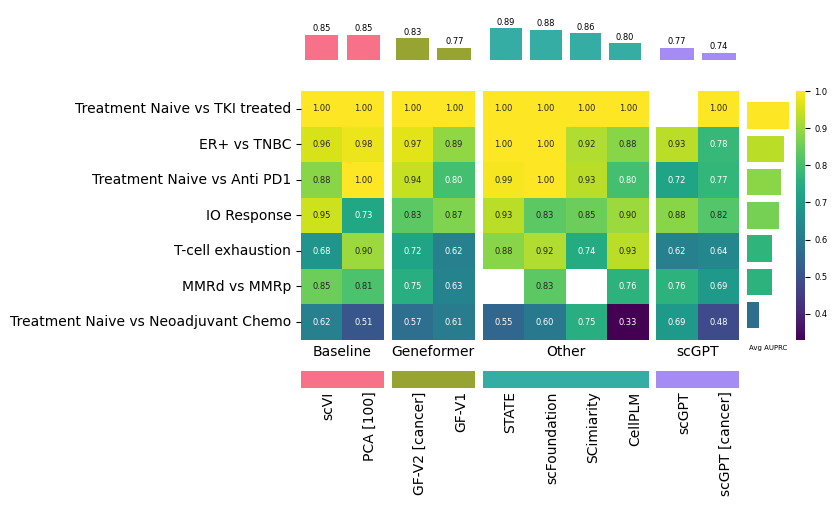

In [153]:
m = 'AUPRC'
clf = 'mil'
plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='./plots')

In [154]:
auprc_df = test_df[['AUPRC', 'model', 'exp', 'group','strategy']]
auprc_df_avg = auprc_df[auprc_df['strategy'] == 'vote']
auprc_df_avg
dd = auprc_df_avg.groupby(['exp', 'group', 'model', 'strategy']).mean().reset_index()
dd['mean'] = dd['AUPRC']
dd['experiment_name'] = dd['exp'] 
dd['experiment'] = dd['model']
heatmap_df_grouped, sorted_models = process_and_sort(dd)
heatmap_df_grouped
# heatmap_df_grouped  = heatmap_df_grouped.drop('luad_cancer_stage', axis=0)

experiment,scVI,PCA [100],GF-V2 [cancer],GF-V1,SCimiarity,STATE,scFoundation,CellPLM,scGPT [cancer],scGPT
experiment_name,,,,,,,,,,
ER+ vs TNBC,1.000000,1.000000,1.000000,0.916667,0.983333,0.966667,1.000000,0.966667,1.000000,0.923333
IO Response,0.950000,0.950000,0.916667,0.916667,0.950000,0.950000,0.950000,0.950000,0.950000,0.950000
MMRd vs MMRp,0.882310,0.878143,0.855079,0.780444,NaN,NaN,0.874626,0.778503,0.732556,0.732556
T-cell exhaustion,0.916667,0.673333,0.780000,0.820000,0.816667,0.740000,0.706667,0.783333,0.800000,0.646667
Treatment Naive vs Anti PD1,0.878737,0.988095,0.933855,0.785874,0.957944,0.929762,1.000000,0.807076,0.773149,0.799226
Treatment Naive vs Neoadjuvant Chemo,0.401905,0.503333,0.555000,0.506667,0.613333,0.721667,0.596667,0.608571,0.511905,0.740000
Treatment Naive vs TKI treated,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN


/tmp/ipykernel_113843/3215541062.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to ./plots/AUPRC_vote.png


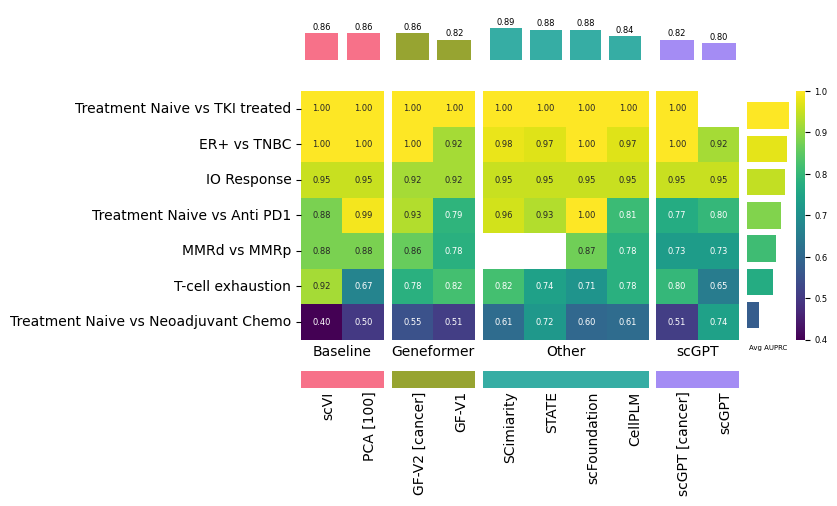

In [155]:
m = 'AUPRC'
clf = 'vote'
plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='./plots')

In [156]:
# for clf in clfs:
#     print(clf)
#     for m in metrics:
#         print(m)
#         heatmap_df = collect_auprc_scores(metric=m,clf=clf, base_dir='./metrics')
#         idx = heatmap_df.experiment.str.contains('continue')
#         heatmap_df= heatmap_df[~idx]
#         idx = heatmap_df.experiment.str.contains('freez')
#         heatmap_df= heatmap_df[~idx]
        
#         idx = heatmap_df.experiment.str.endswith('k')
#         heatmap_df= heatmap_df[~idx]
        
#         idx = heatmap_df.experiment.str.endswith('batch')
#         heatmap_df= heatmap_df[~idx]
    
#         idx = heatmap_df.experiment.str.endswith('_')
#         heatmap_df= heatmap_df[~idx]
        
#         idx = heatmap_df.experiment.str.endswith('all')
#         heatmap_df= heatmap_df[~idx]
        
#         # heatmap_df.group = heatmap_df.group.map(group_map)
#         heatmap_df.experiment = heatmap_df.experiment.map(lambda x: model_name_map.get(x, x))
#         heatmap_df.experiment_name = heatmap_df.experiment_name.map(experiment_name_map)
#         # heatmap_df['experiment_name'] = heatmap_df.experiment
#         heatmap_df_grouped, sorted_models = process_and_sort(heatmap_df)
#         plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='./plots')
        